In [1]:
from atomica.models import MultiClassClassifierModel, MultiLabelClassifierModel, ResidueClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset
from atomica.trainers import Trainer

from multiclass_metrics import compute_multiclass_metrics
from multilabel_metrics import compute_multilabel_metrics

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from glob import glob

MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/"
DATA_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks"

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_model(model_checkpoint: str, task_name: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    if task_name == "RNAGo":
        return MultiLabelClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Ligand":
        return MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Protein" or task_name == "RNA_Site":
        return ResidueClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    else:
        raise ValueError(f"Task name {task_name} not supported")

def get_atomica_results(model_checkpoint, task_name, split="val", threshold=0.5, recompute=False):
    """
    Get ATOMICA model results for a given checkpoint.
    
    Parameters:
    -----------
    class_thresholds : dict or list, optional
        For multiclass tasks (RNA_Ligand), specify thresholds for each class.
        If dict: {0: threshold_0, 1: threshold_1, 2: threshold_2}
        If list: [threshold_0, threshold_1, threshold_2]
        If None, falls back to argmax.
    """
    if not recompute and os.path.exists(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet")):
        results = pd.read_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
        if 'ckpt' in results.columns and model_checkpoint in results['ckpt'].tolist():
            return results
    dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed_RNA.parquet")
    model = get_model(model_checkpoint, task_name)

    model.eval()
    model.to("cuda")
    batch_size = 1

    atomica_preds_run = []
    for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc="Running inference"):
        with torch.no_grad():
            batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
            batch = MultiClassLabelledPDBDataset.collate_fn(batch)
            batch = Trainer.to_device(batch, "cuda")
            atomica_preds_run.append(model.infer(batch).cpu().numpy())
    atomica_preds = np.concatenate(atomica_preds_run)
    
    if task_name == "RNA_Protein":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_ids = sum([[x['id']] * len(x['label']) for x in dataset.data], [])
        atomica_preds = atomica_preds.flatten()
    elif task_name == "RNA_Site":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_preds = atomica_preds.flatten()
        atomica_ids = []
        for x in dataset.data:
            assert len(x['label']) == len(x['block_to_pdb_indexes'])
            for _, pdb_index in sorted(x['block_to_pdb_indexes'].items()):
                atomica_ids.append(x['id'] + '_' + str(pdb_index))
    else:
        atomica_labels = np.array([x['label'] for x in dataset.data])
        atomica_ids = np.array([x['id'] for x in dataset.data])
        atomica_labels = list(atomica_labels)
        atomica_preds = list(atomica_preds)
    atomica_results = pd.DataFrame({
        'id': atomica_ids,
        'label': atomica_labels,
        'pred_probability': atomica_preds,
    })
    if task_name == "RNA_Ligand":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: np.argmax(x))
    elif task_name == "RNAGo":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: (x > threshold).astype(int))
    else:
        atomica_results['pred'] = (atomica_results['pred_probability'] > threshold).astype(int)

    atomica_results['ckpt'] = model_checkpoint
    atomica_results.to_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    return atomica_results

In [8]:
valid_versions = []

max_epoch = 1000

files = glob(f"{MODEL_DIR}/RNA_Ligand/**/version_*/args.json")
for file in files:
    with open(file, "r") as f:
        args = json.load(f)
    if args['train_set'].endswith("_processed_RNA.parquet"):
        # if 'RNAGo' in args['train_set'] and args['run_name'] != "RNAGo_lr2e-5_final_lr2e-5_gradclip1.0_block_sampling_p_keep0.7_block_sampling_p_none0.5_weighted_lossFalse_f1_macro":
        #     continue
        ckpt = args['pretrain_weights']
        if ckpt is not None:
            continue # should be no pretrain ckpt
        version = os.path.dirname(file)
        topk_map = os.path.join(version, "checkpoint/topk_map.txt")
        if not os.path.exists(topk_map):
            continue
        
        curr_min_epoch = max_epoch
        with open(topk_map, "r") as f:
            for line in f.readlines():
                metric, top_ckpt = line.strip().split(": ")
                epoch = int(top_ckpt.split("epoch")[1].split("_")[0])
                if epoch < max_epoch:
                    break
                # curr_min_epoch = min(curr_min_epoch, epoch)
                # if curr_min_epoch - epoch > patience:
                #     break
        metric = float(metric)
        valid_versions.append((metric, os.path.basename(version), top_ckpt, ckpt))

valid_versions = pd.DataFrame(valid_versions, columns=["metric", "version", "top_ckpt", "pretrain_ckpt"])
valid_versions = valid_versions.sort_values(by="metric", ascending=False).reset_index(drop=True)

In [9]:
valid_versions

,metric,version,top_ckpt,pretrain_ckpt
0,0.268519,version_282,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,None
1,0.268519,version_283,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,None
2,0.268519,version_287,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,None
3,0.268519,version_286,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,None
4,0.125786,version_284,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,None
5,0.056738,version_285,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,None


In [11]:
valid_versions["top_ckpt"].tolist()[:5]

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_282/checkpoint/epoch0_step0.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_283/checkpoint/epoch0_step0.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_287/checkpoint/epoch0_step0.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_286/checkpoint/epoch0_step0.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_284/checkpoint/epoch0_step1.ckpt']

In [6]:
valid_versions[valid_versions['pretrain_ckpt'] != 'checkpoints/pretrain/pretrain_model_weights.pt']["top_ckpt"].tolist()[:5]

[]

In [18]:
all_metrics = []

to_run = valid_versions["top_ckpt"].tolist()[:5]
for ckpt in tqdm(to_run, desc="Computing metrics", total=len(to_run)):
    ckpt = ckpt.replace(".ckpt", ".pt")
    val_results = get_atomica_results(ckpt, "RNAGo", "val")
    test_results = get_atomica_results(ckpt, "RNAGo", "test")

    best_f1_threshold = 0.0
    best_f1_score = 0.0
    best_val_metrics = None
    f1_thresholds = np.linspace(0.0, 0.5, 6)
    for threshold in f1_thresholds:
        metrics = compute_multilabel_metrics(
            y_true=np.stack(val_results['label']),
            y_proba=np.stack(val_results['pred_probability']),
            threshold=threshold
        )
        if metrics.f1_weighted > best_f1_score:
            best_f1_score = metrics.f1_weighted
            best_f1_threshold = threshold
            best_val_metrics = metrics
    atomica_preds = np.stack(test_results['pred_probability']) > best_f1_threshold

    metrics = compute_multilabel_metrics(
        y_true=np.stack(test_results['label']),
        y_proba=np.stack(test_results['pred_probability']),
        threshold=best_f1_threshold
    )

    all_metrics.append({
        "ckpt": ckpt,
        "version": os.path.basename(os.path.dirname(os.path.dirname(ckpt))),
        "val_f1_macro": best_val_metrics.f1_macro,
        "val_f1_micro": best_val_metrics.f1_micro,
        "val_f1_weighted": best_val_metrics.f1_weighted,
        "val_0": best_val_metrics.per_label[0]['f1'],
        "val_1": best_val_metrics.per_label[1]['f1'],
        "val_2": best_val_metrics.per_label[2]['f1'],
        "val_3": best_val_metrics.per_label[3]['f1'],
        "val_4": best_val_metrics.per_label[4]['f1'],
        "test_f1_macro": metrics.f1_macro,
        "test_f1_micro": metrics.f1_micro,
        "test_f1_weighted": metrics.f1_weighted,
        "test_0": metrics.per_label[0]['f1'],
        "test_1": metrics.per_label[1]['f1'],
        "test_2": metrics.per_label[2]['f1'],
        "test_3": metrics.per_label[3]['f1'],
        "test_4": metrics.per_label[4]['f1'],
    })

all_metrics = pd.DataFrame(all_metrics)

Computing metrics: 100%|██████████| 5/5 [00:00<00:00,  5.12it/s]


In [19]:
all_metrics.sort_values(by="val_f1_macro", ascending=False, inplace=True)
all_metrics

,ckpt,version,val_f1_macro,val_f1_micro,val_f1_weighted,val_0,val_1,val_2,val_3,val_4,test_f1_macro,test_f1_micro,test_f1_weighted,test_0,test_1,test_2,test_3,test_4
3,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,version_35,0.942623,0.973684,0.972363,0.984615,0.8,0.947368,0.981132,1.000000,0.888312,0.823529,0.832274,0.761905,1.0,0.952381,1.000000,0.727273
1,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,version_27,0.920009,0.927152,0.927423,0.968750,1.0,0.900000,0.897959,0.833333,0.876970,0.776471,0.757382,1.000000,1.0,0.900000,1.000000,0.484848
0,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,version_26,0.915680,0.922078,0.921279,0.925373,0.8,0.947368,0.905660,1.000000,0.697898,0.684211,0.785701,0.390244,1.0,0.842105,0.400000,0.857143
2,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,version_32,0.887428,0.935897,0.935860,0.984615,0.8,0.818182,0.945455,0.888889,0.541111,0.495575,0.530733,0.355556,1.0,0.900000,0.200000,0.250000
4,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,version_41,0.854525,0.891892,0.891778,0.935484,0.8,0.857143,0.880000,0.800000,0.885018,0.913043,0.914246,0.941176,1.0,0.952381,0.666667,0.864865


In [20]:
all_metrics['ckpt'].to_list()

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_35/checkpoint/epoch114_step15755.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_27/checkpoint/epoch362_step50094.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_26/checkpoint/epoch216_step30597.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_32/checkpoint/epoch91_step12696.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_41/checkpoint/epoch120_step16698.pt']

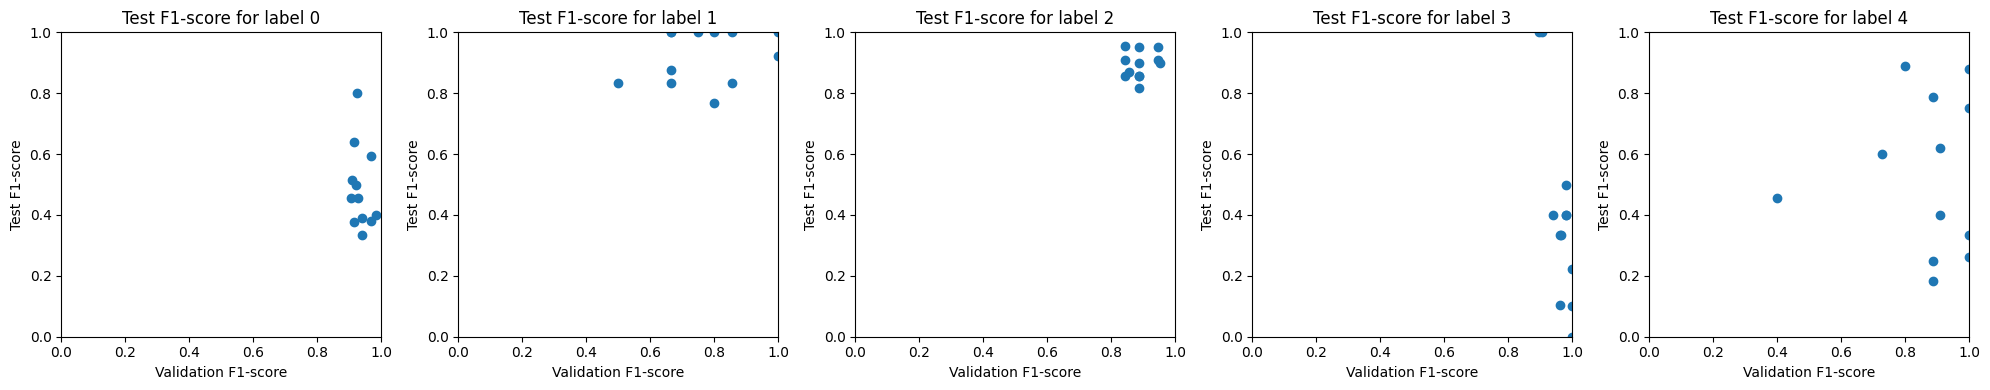

In [42]:
fig, axes = plt.subplots(1,5, figsize=(20, 4))
for i, ax in enumerate(axes):
    ax.scatter(all_metrics[f'val_{i}'], all_metrics[f'test_{i}'])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"Test F1-score for label {i}")
    ax.set_xlabel("Validation F1-score")
    ax.set_ylabel("Test F1-score")
plt.tight_layout()
plt.show()

In [37]:
all_metrics.sort_values(by=["test_0", "test_f1_macro"], ascending=False).iloc[1]['ckpt']

'/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_118/checkpoint/epoch172_step21452.pt'

In [38]:
all_metrics.sort_values(by=["test_3", "test_f1_macro"], ascending=False).iloc[1]['ckpt']

'/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_118/checkpoint/epoch172_step21452.pt'

In [39]:
all_metrics.sort_values(by=["test_4", "test_f1_macro"], ascending=False).iloc[1]['ckpt']

'/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_91/checkpoint/epoch221_step27528.pt'

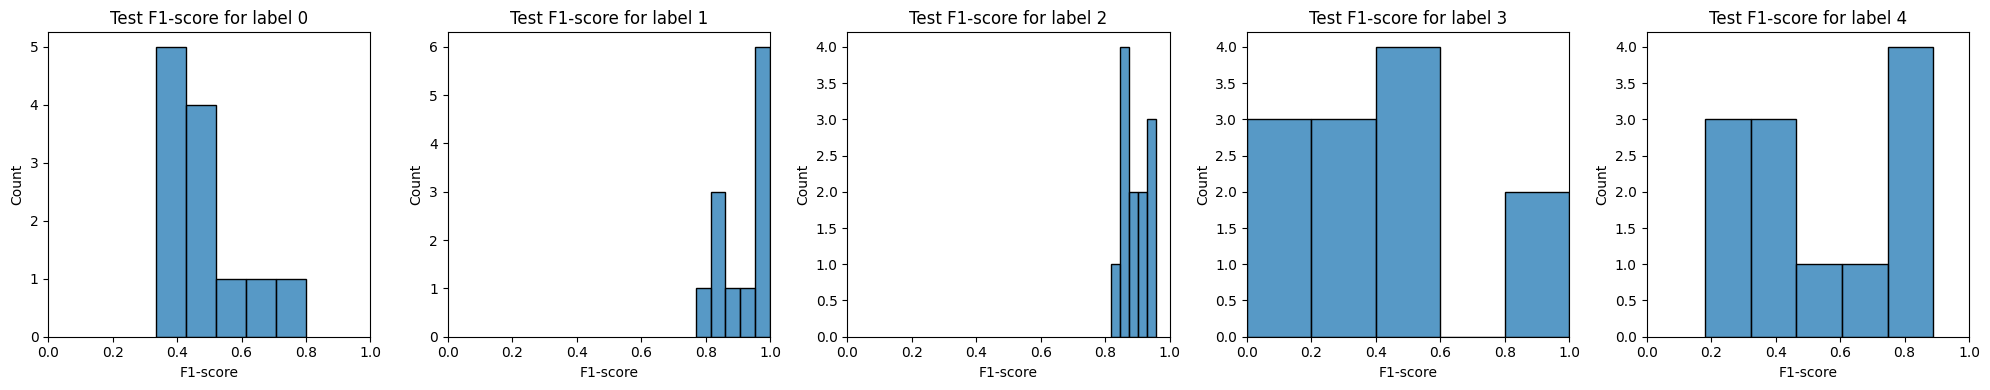

In [25]:
fig, axes = plt.subplots(1,5, figsize=(20, 4))
for i, ax in enumerate(axes):
    sns.histplot(all_metrics[f"test_{i}"], ax=ax)
    ax.set_title(f"Test F1-score for label {i}")
    ax.set_xlabel("F1-score")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


In [18]:
best_ckpts = all_metrics['ckpt'].tolist()
[best_ckpts[0], best_ckpts[1], best_ckpts[3]]

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_115/checkpoint/epoch269_step33480.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_91/checkpoint/epoch221_step27528.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_88/checkpoint/epoch242_step30132.pt']

In [20]:
metrics.per_label

{0: {'precision': 0.24242424242424243,
  'recall': 1.0,
  'f1': 0.3902439024390244,
  'support': 8.0,
  'jaccard': 0.24242424242424243},
 1: {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'support': 7.0,
  'jaccard': 1.0},
 2: {'precision': 0.9,
  'recall': 0.8181818181818182,
  'f1': 0.8571428571428571,
  'support': 11.0,
  'jaccard': 0.75},
 3: {'precision': 0.125,
  'recall': 1.0,
  'f1': 0.2222222222222222,
  'support': 1.0,
  'jaccard': 0.125},
 4: {'precision': 1.0,
  'recall': 0.1,
  'f1': 0.18181818181818182,
  'support': 20.0,
  'jaccard': 0.1}}